M4: mu ~ N(0.1, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20, N=100, S=4D

In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions


def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)


bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm

In [3]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
mu_prior_mean = 0.1
mu_prior_std = 1
likelihood_std = 1

In [4]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)


def likelihood(mu):
    x = RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)


simulator = bf.make_simulator([prior, likelihood])

In [5]:
# adapter
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .rename("mu", "inference_variables")
    .rename("x", "summary_variables")
)

In [6]:
# networks
summary_net = bf.networks.DeepSet(summary_dim=4 * num_dims, base_distribution="normal")

inference_net = bf.networks.CouplingFlow()

In [7]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    standardize="all",
)
epochs = 100
batch_size = 64
num_batches_per_epoch = 128
learning_rate = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4, decay_steps=epochs * num_batches_per_epoch
)
workflow.approximator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate)
)

In [8]:
history = workflow.fit_online(
    epochs=epochs, batch_size=batch_size, num_batches_per_epoch=num_batches_per_epoch
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - CouplingFlow/loss: 25.9618 - DeepSet/loss: 0.3467 - loss: 26.3085
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - CouplingFlow/loss: 14.6515 - DeepSet/loss: 0.3605 - loss: 15.0121
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - CouplingFlow/loss: 5.9998 - DeepSet/loss: 0.4091 - loss: 6.4089
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - CouplingFlow/loss: 0.0563 - DeepSet/loss: 0.3798 - loss: 0.4361  
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - CouplingFlow/loss: -3.2247 - DeepSet/loss: 0.3362 - loss: -2.8885
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - CouplingFlow/loss: -5.0108 - DeepSet/loss: 0.3123 - loss: -4.6985
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - CouplingFlow/loss: -6.2566 - DeepSet/loss: 0.2977 - loss: -5.9589
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - CouplingFlow/loss: -7.1940 - DeepSet/loss: 0.2913 - loss: -6.9026
Epoch 9/100
128/128 ━━━━━

INFO:bayesflow:Training completed in 15.54 minutes.


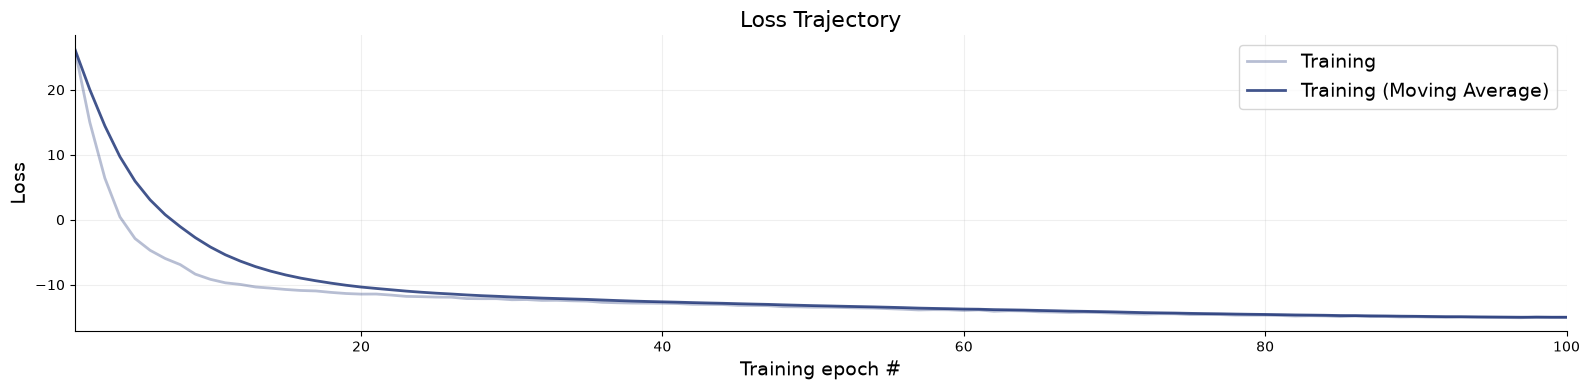

In [9]:
f = bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000  # number of posterior samples
val_sims = simulator.sample(200)  # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()

INFO:bayesflow:Sampling completed in 1.09 seconds.


dict_keys(['mu'])

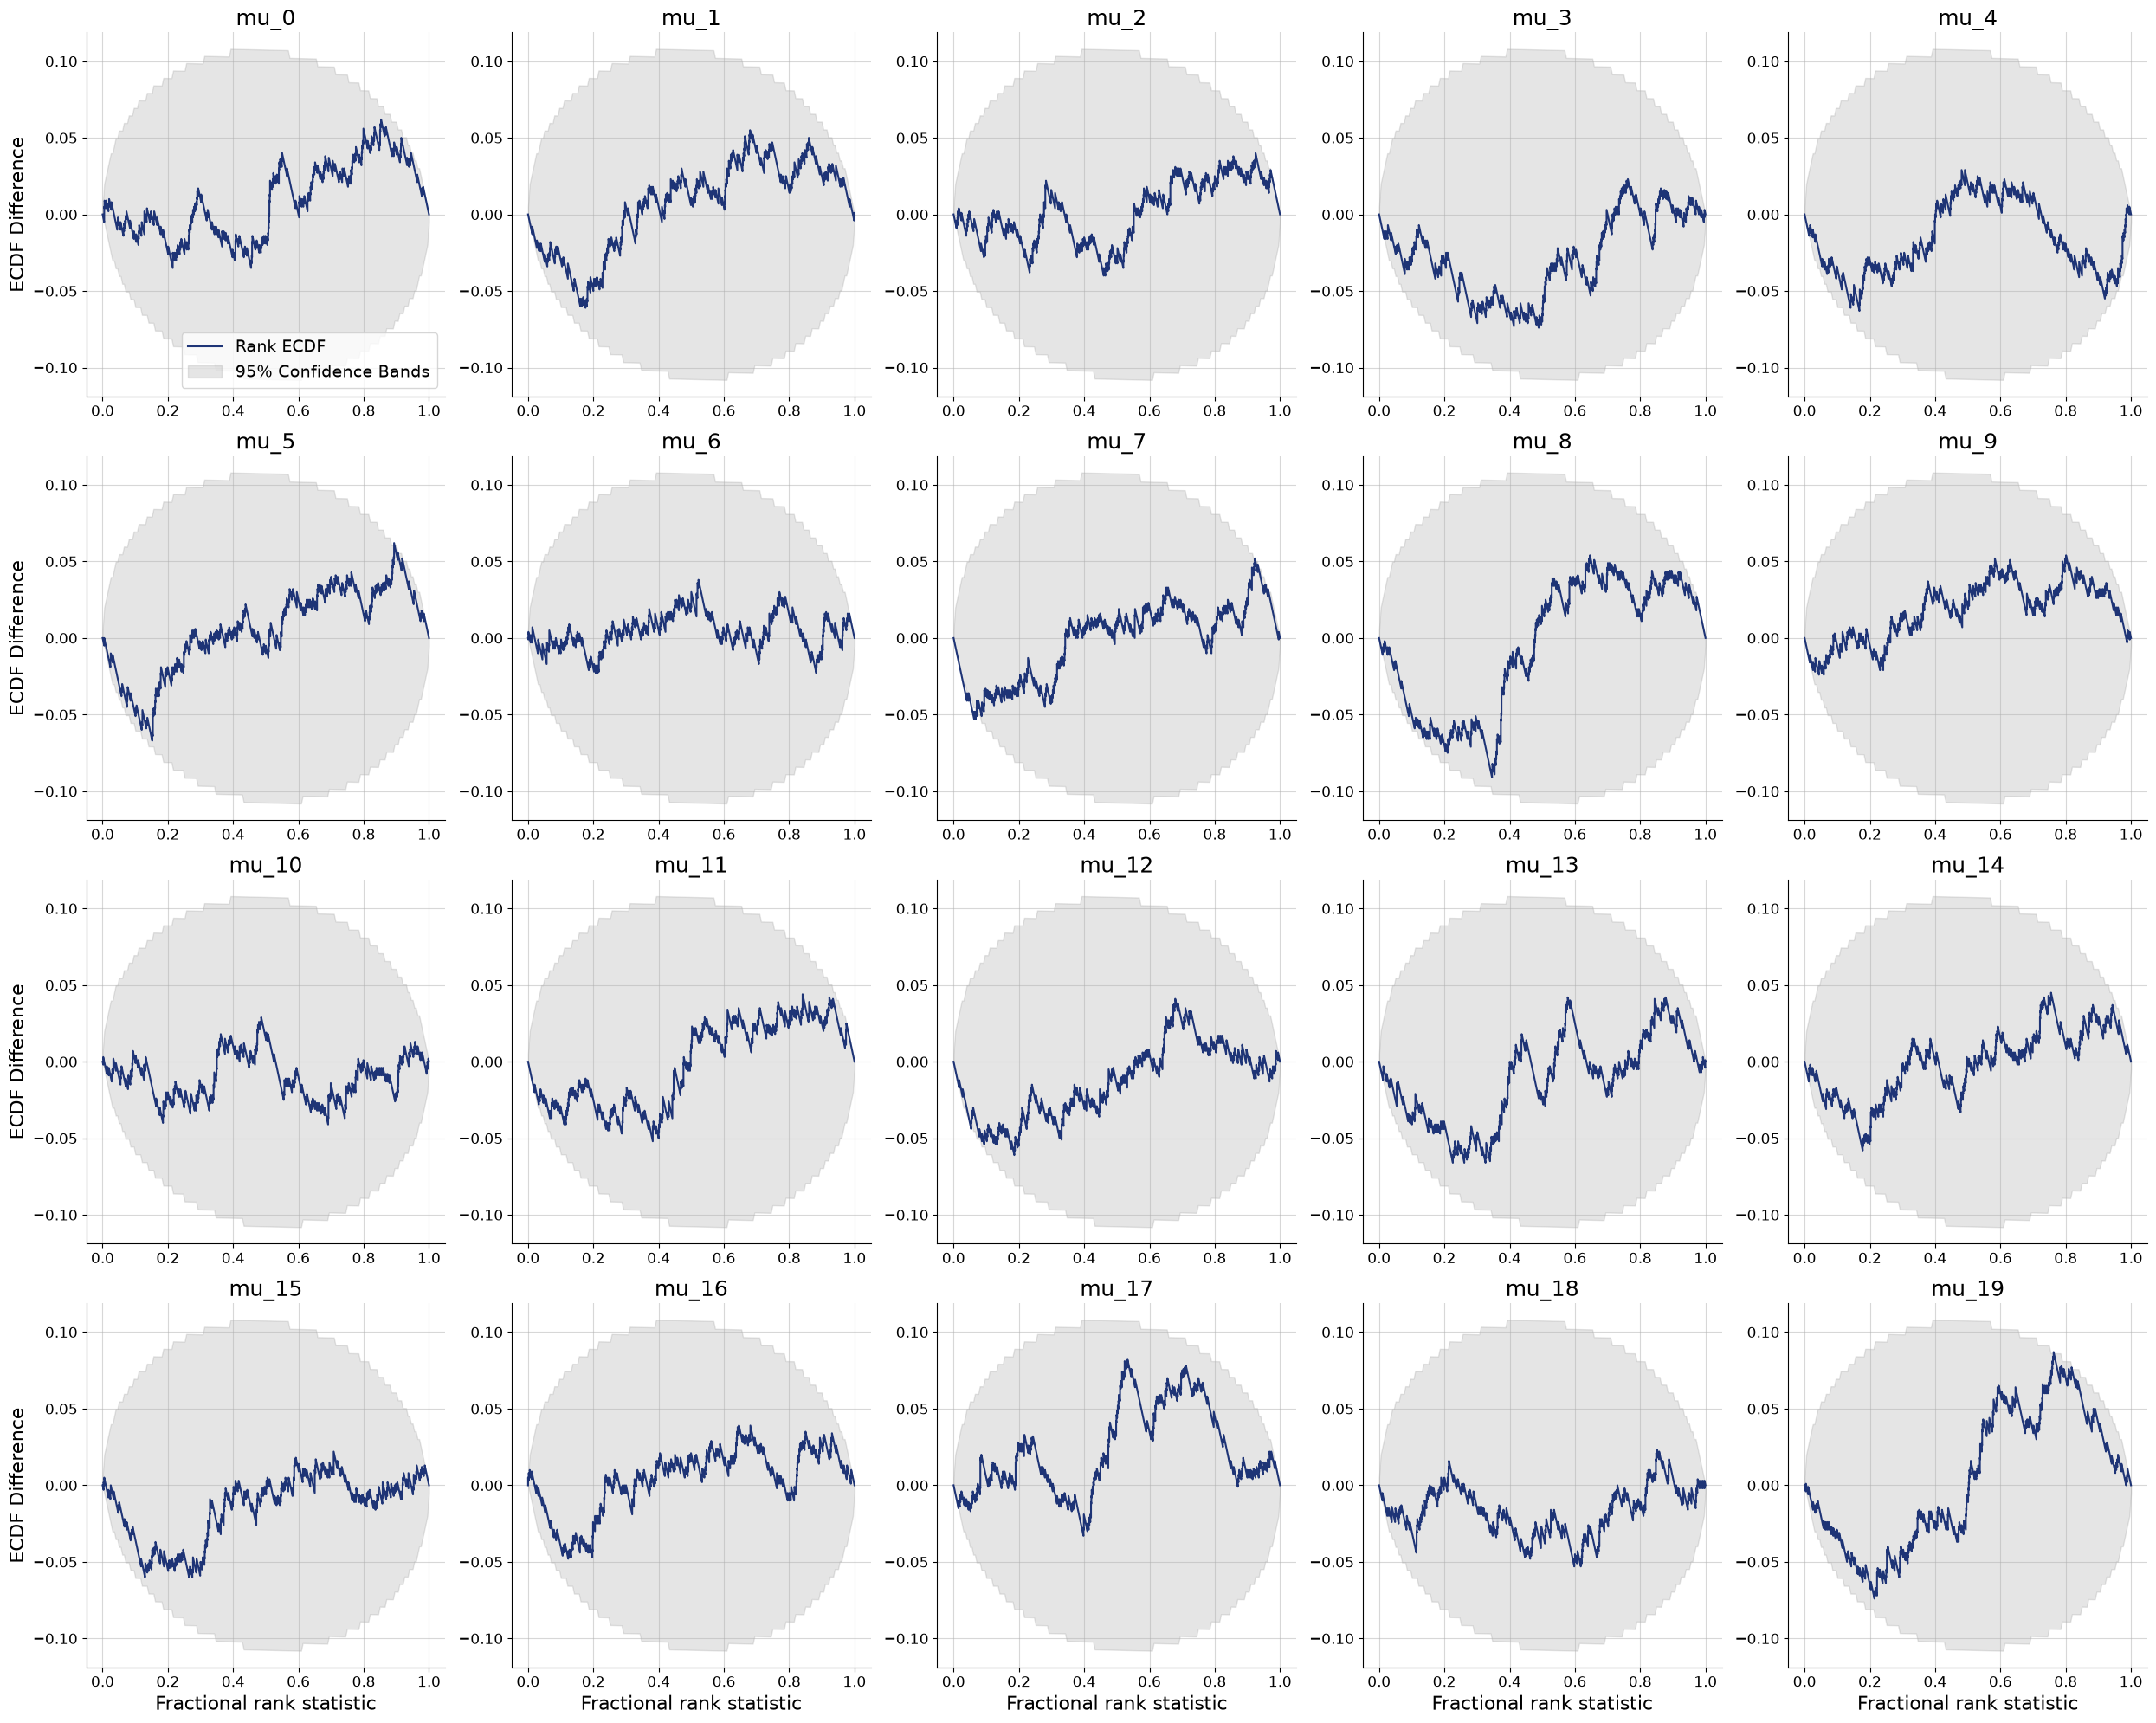

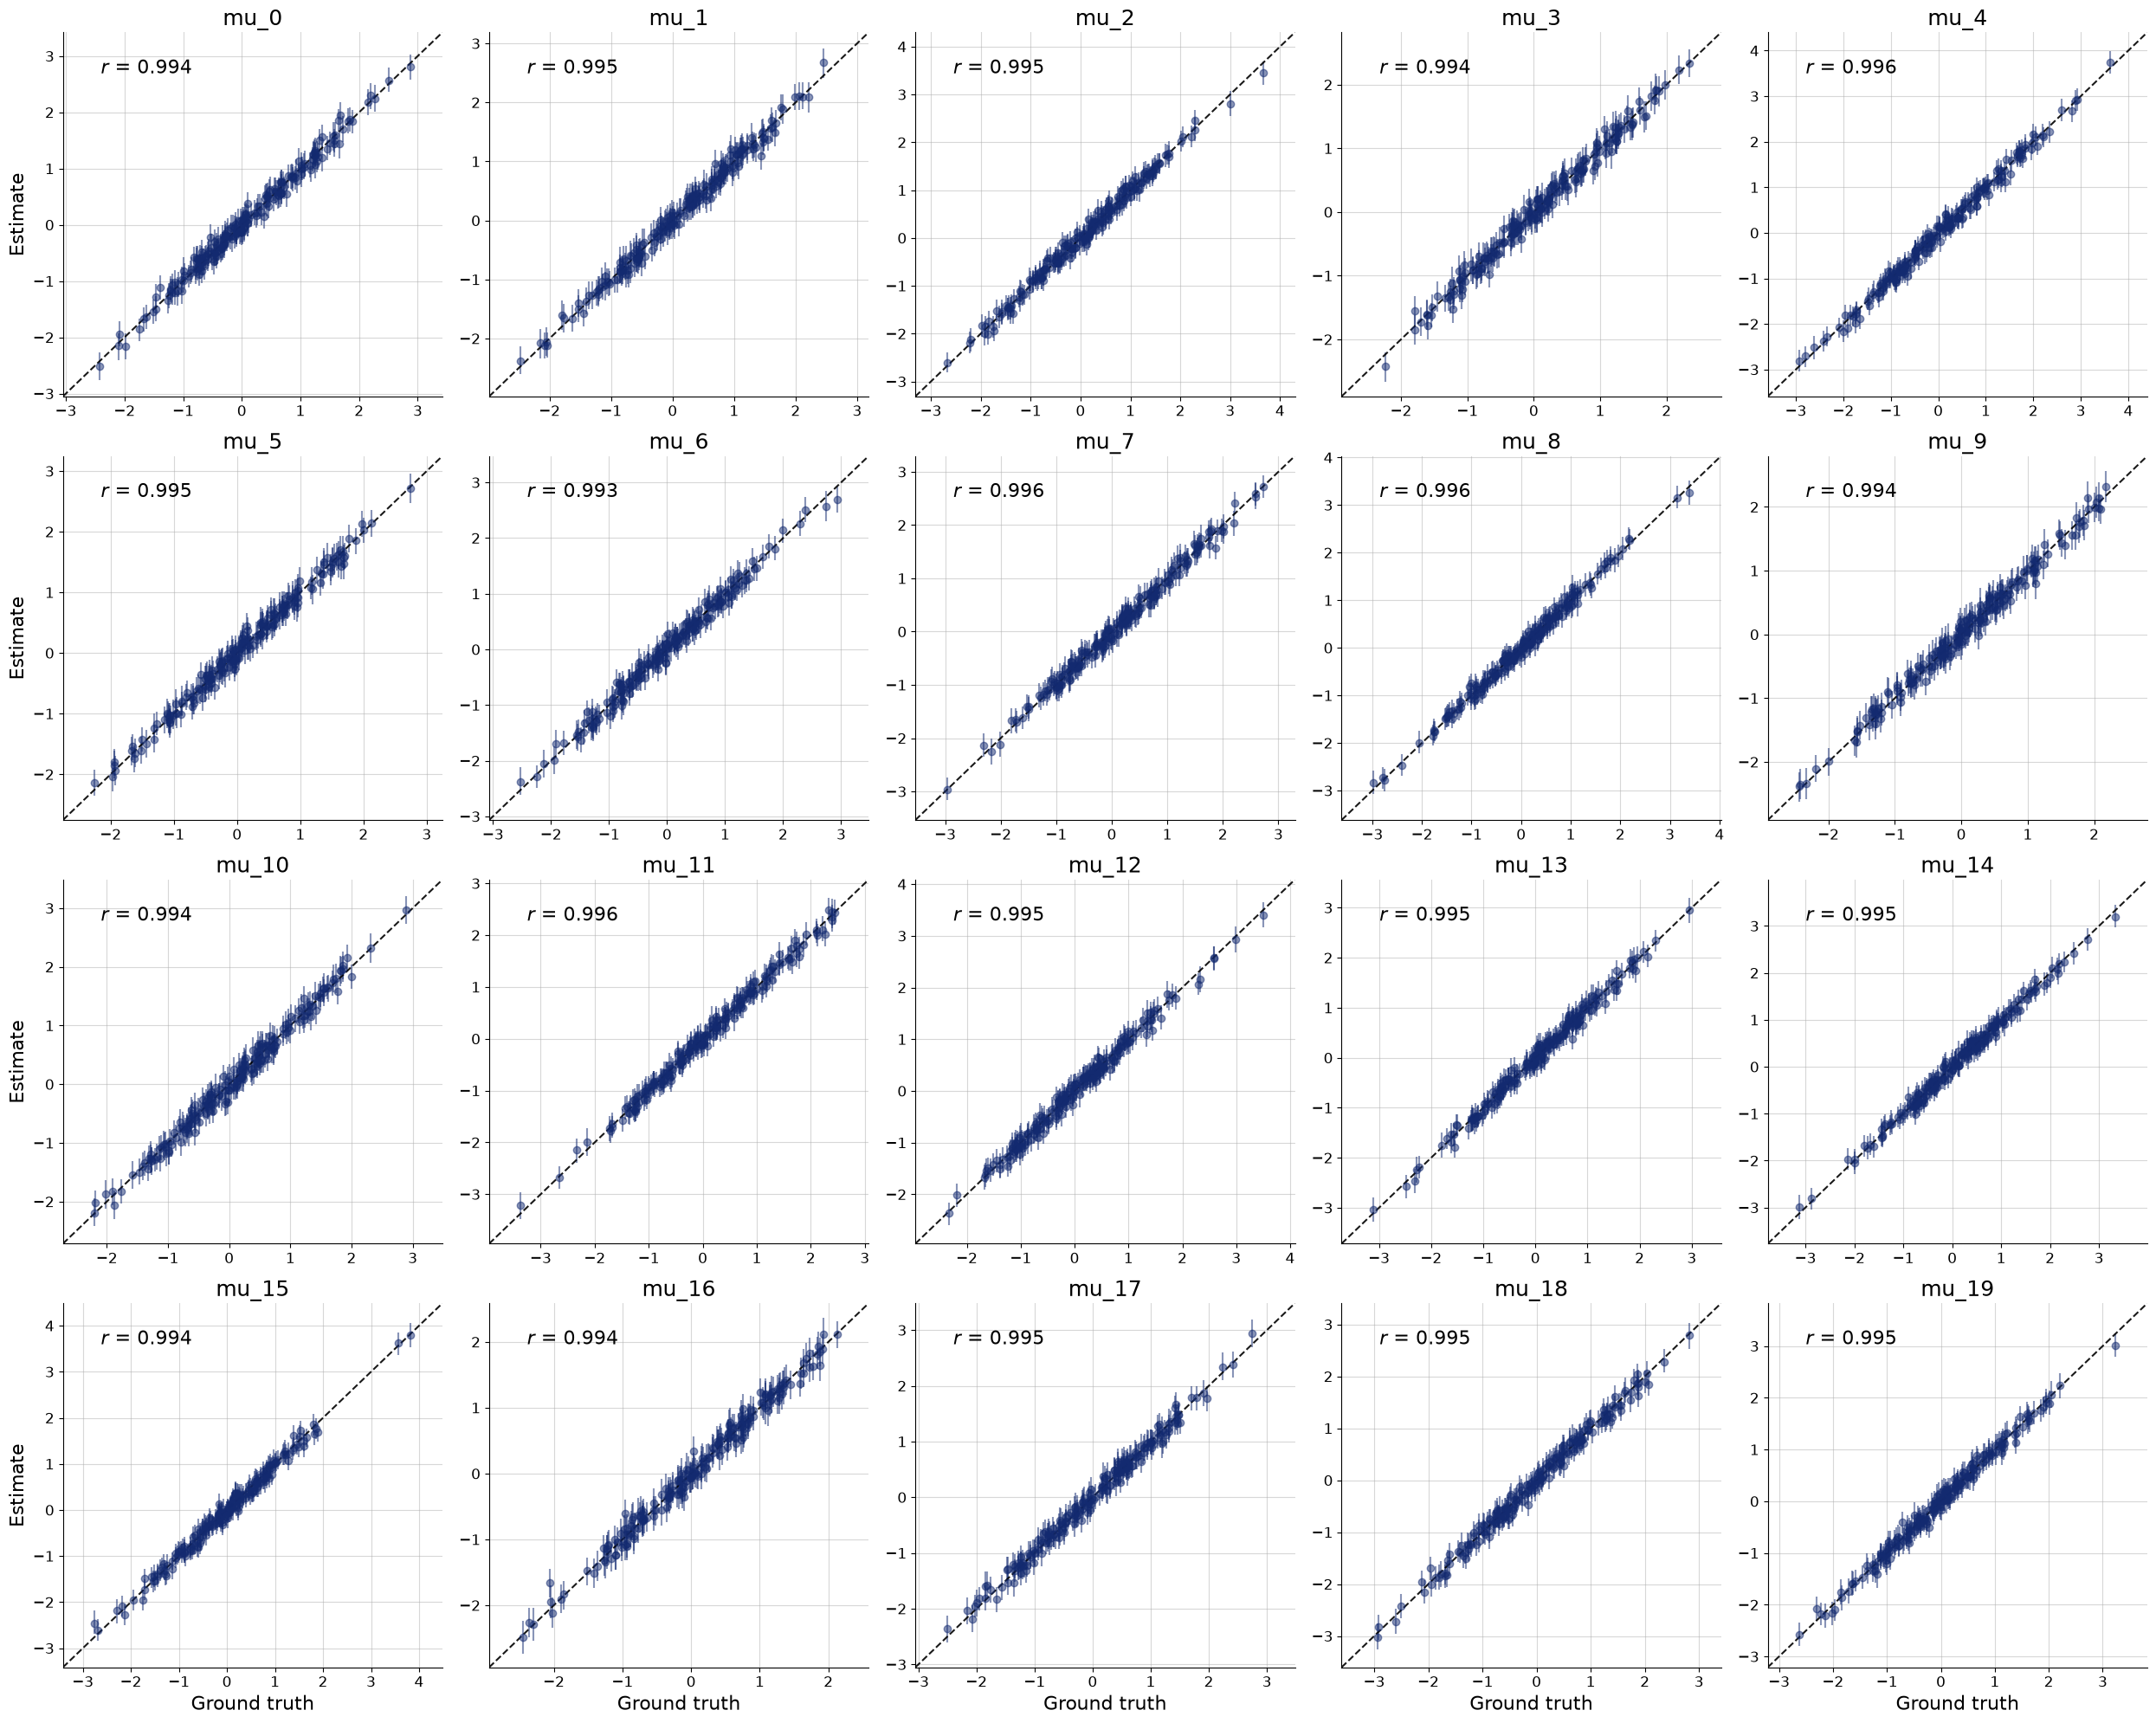

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = (
    Path(
        "/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks"
    )
    / "m4_s_80d_100n.keras"
)
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [13]:
# load approximator
filepath = (
    Path(
        "/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks"
    )
    / "m4_s_80d_100n.keras"
)
approximator = keras.saving.load_model(filepath)

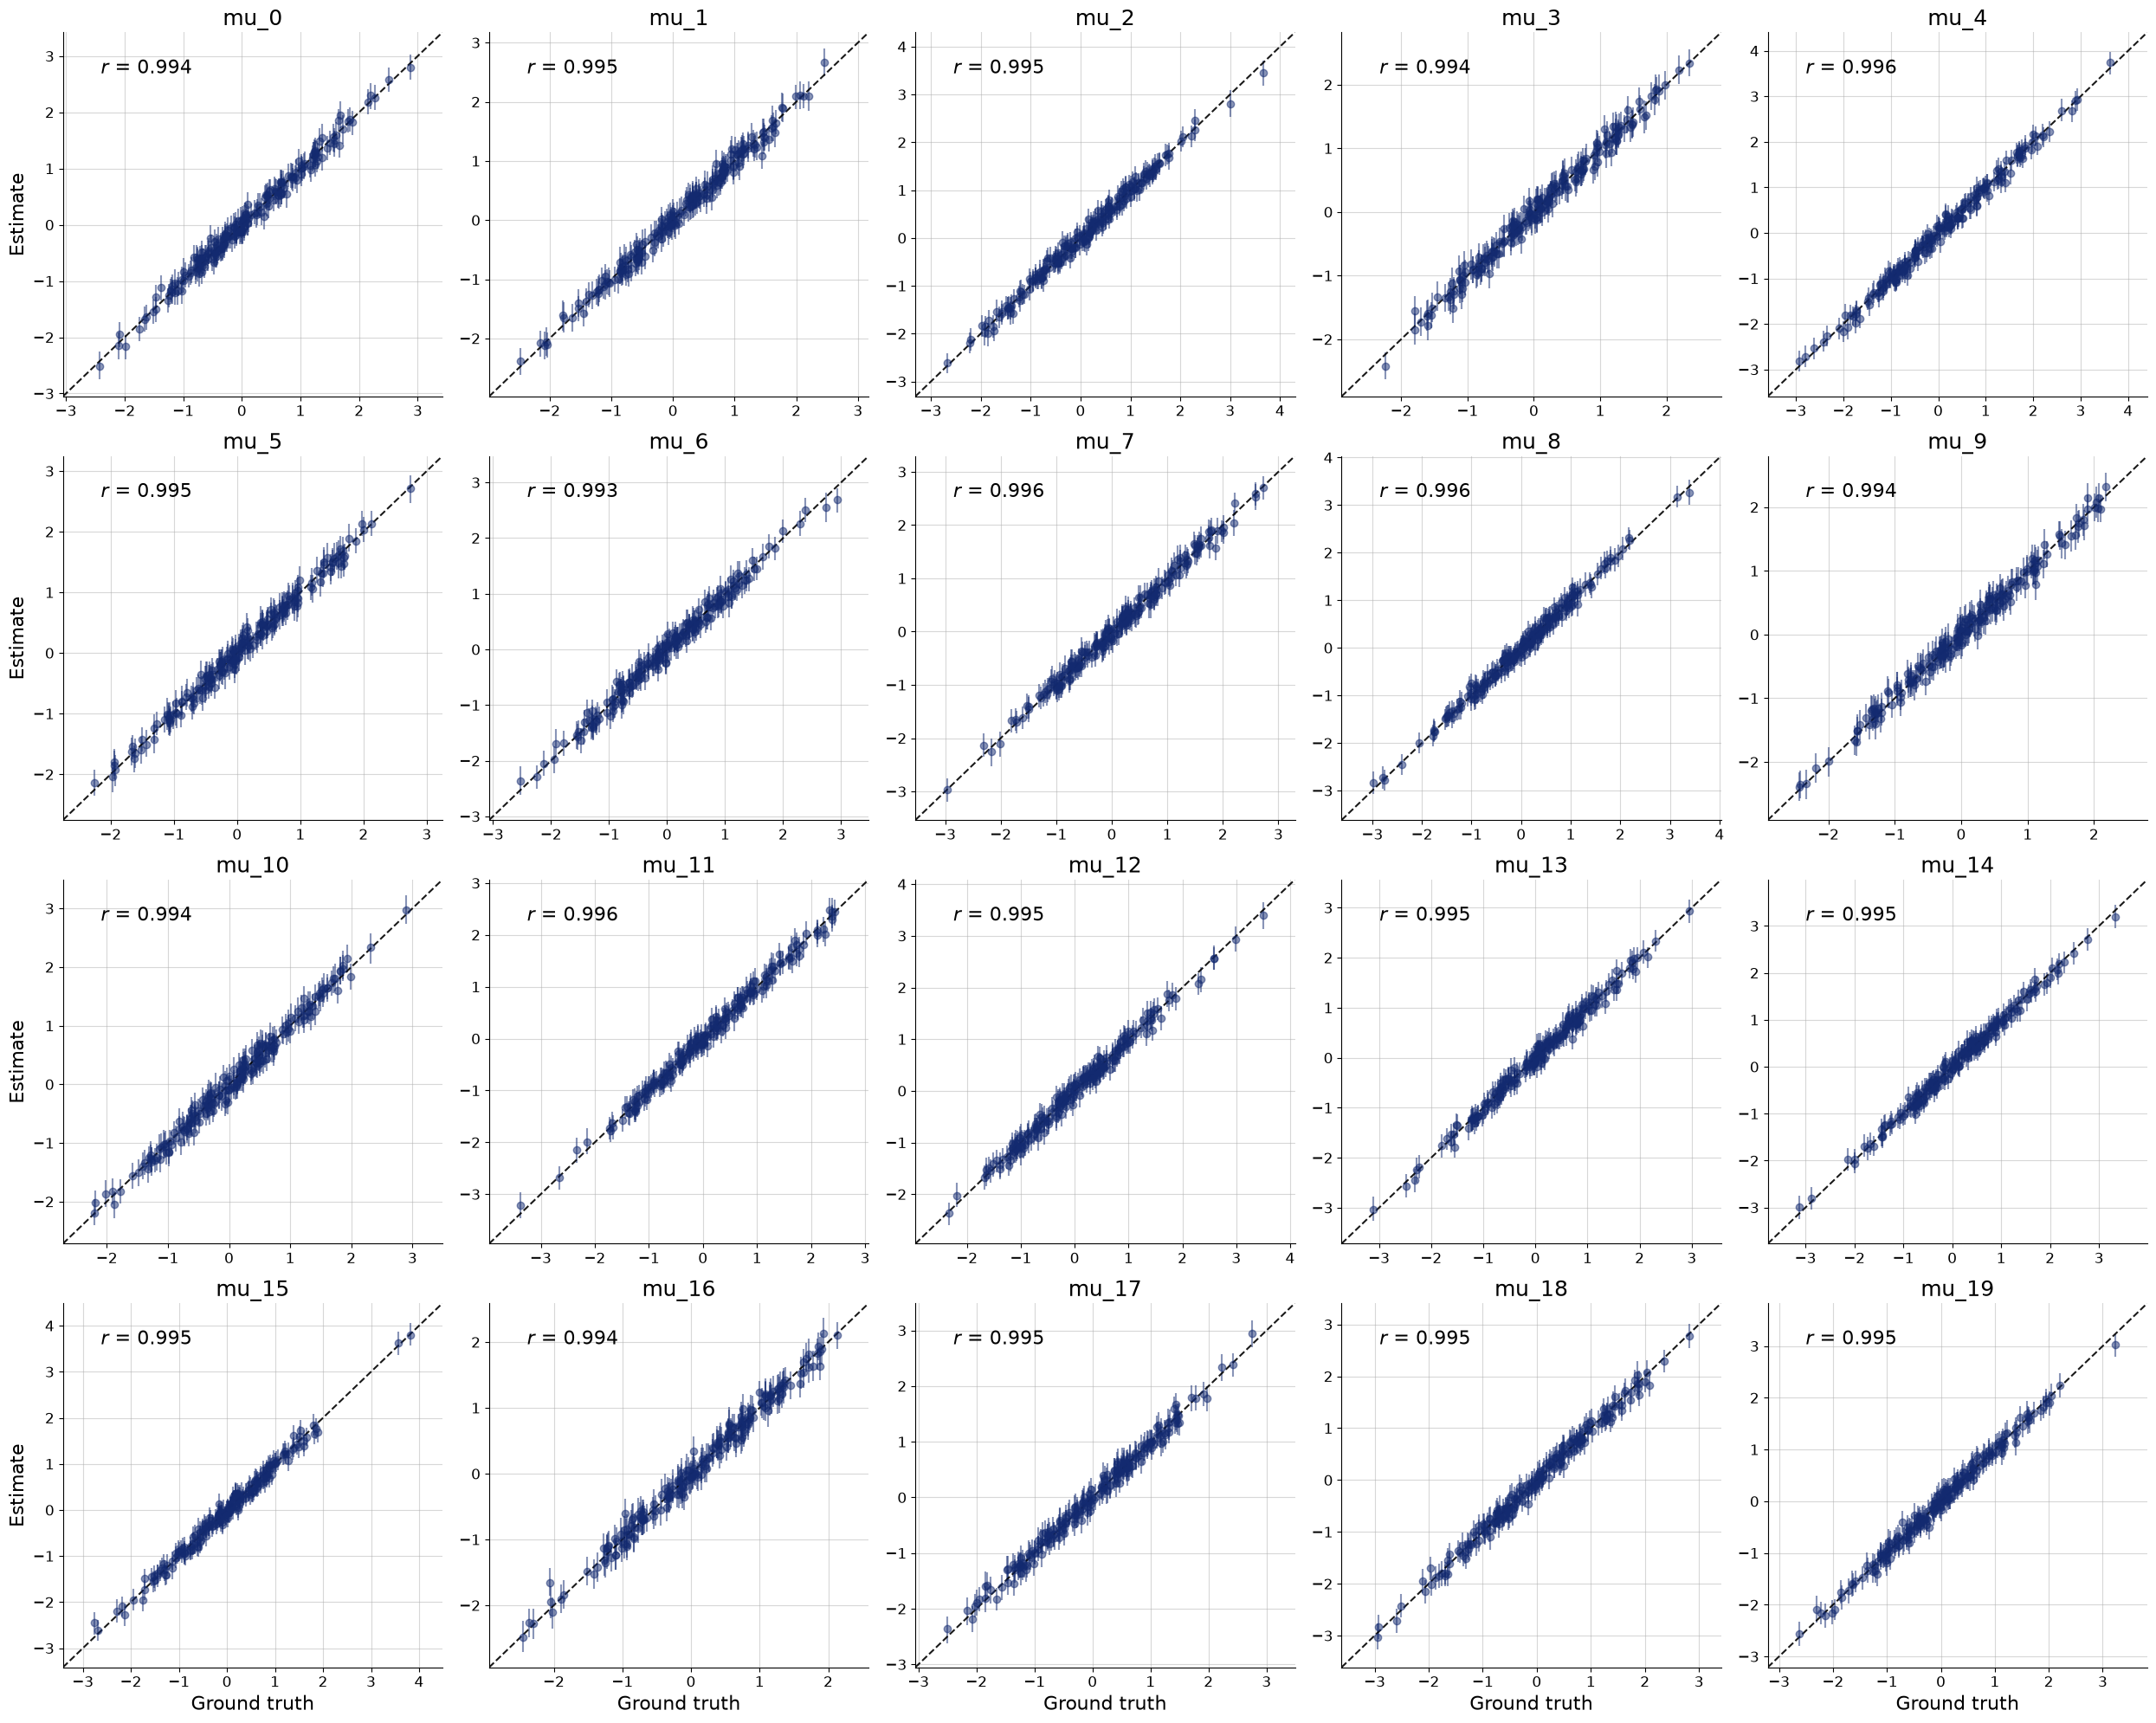

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)